In [ ]:
import pandas as pd

df = pd.read_csv("../data/raw/sample_sales.csv", parse_dates=["date"])

print(f"Shape: {df.shape}")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")
df.head(10)

In [11]:
df.groupby("sku")["sales"].describe().round(1)

,count,mean,std,min,25%,50%,75%,max
sku,,,,,,,,
SKU-001,1096.0,307.6,87.6,117.0,240.0,290.0,367.0,631.0
SKU-002,1096.0,92.1,33.9,0.0,69.0,94.0,117.0,183.0
SKU-003,1096.0,861.5,267.6,224.0,656.8,805.0,1087.2,1628.0
SKU-004,1096.0,28.3,16.7,0.0,16.0,28.0,40.2,91.0


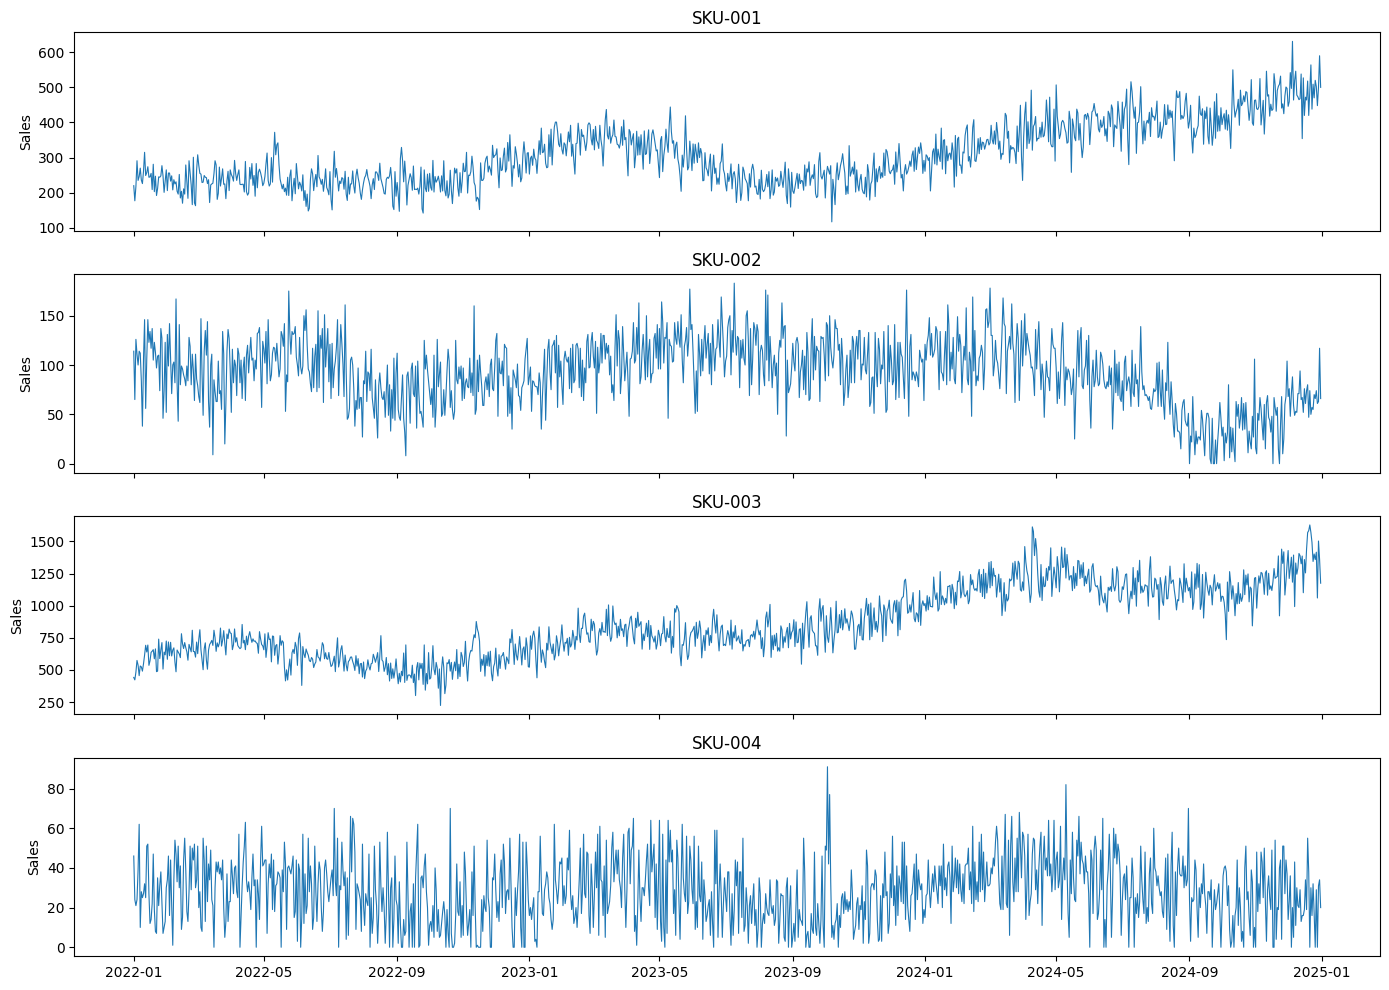

In [12]:
import matplotlib.pyplot as plt

skus = df["sku"].unique()
fig, axes = plt.subplots(len(skus), 1, figsize=(14, 10), sharex=True)

for ax, sku in zip(axes, skus):
    data = df[df["sku"] == sku]
    ax.plot(data["date"], data["sales"], linewidth=0.8)
    ax.set_title(sku)
    ax.set_ylabel("Sales")

plt.tight_layout()
plt.show()

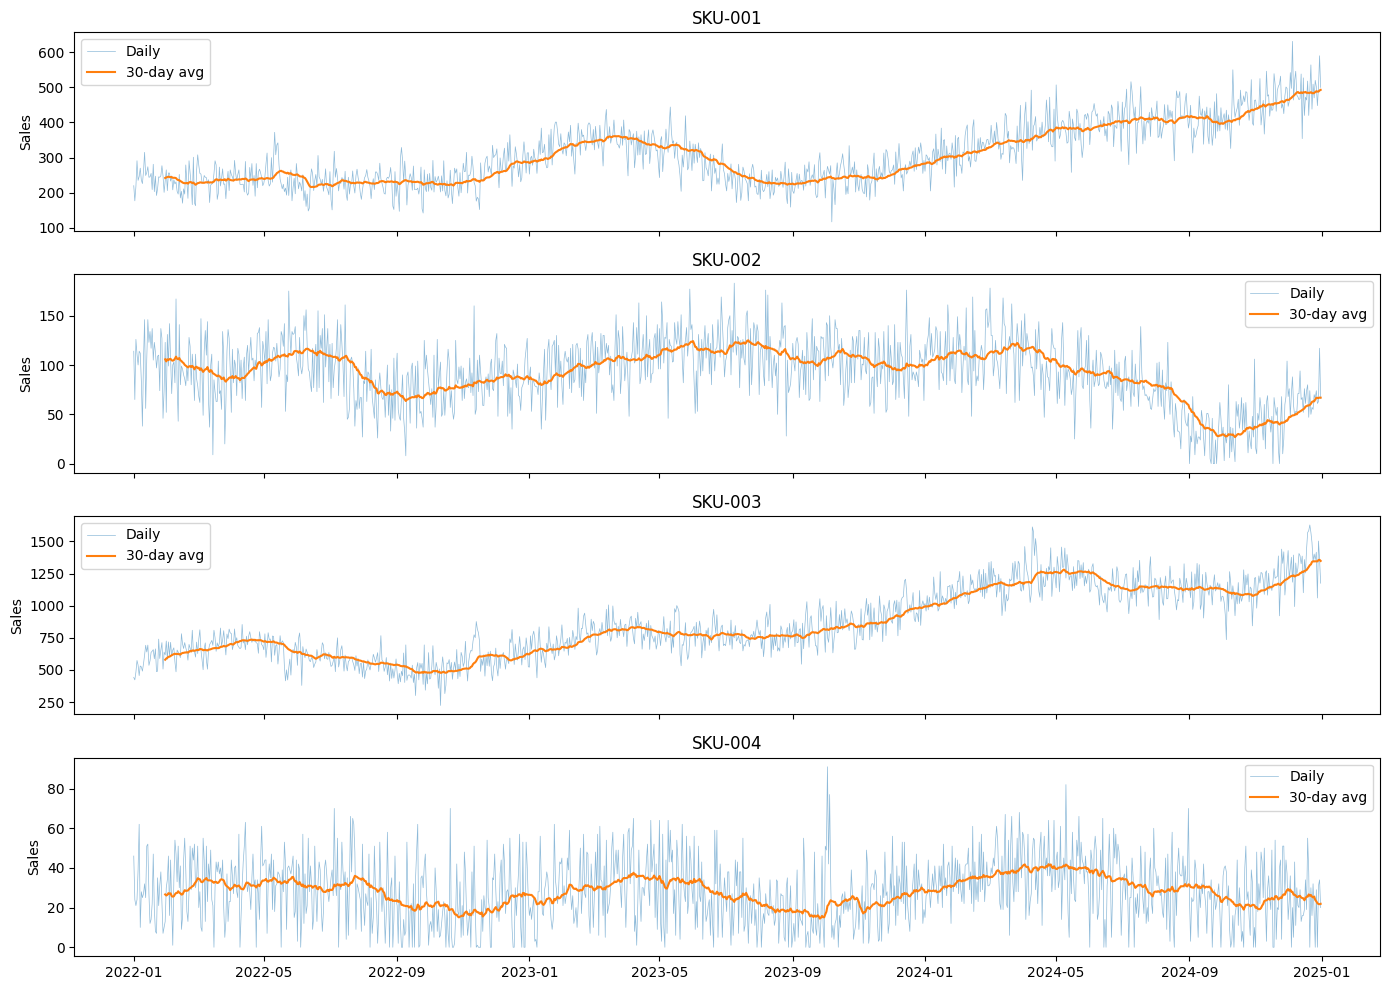

In [13]:
fig, axes = plt.subplots(len(skus), 1, figsize=(14, 10), sharex=True)

for ax, sku in zip(axes, skus):
    data = df[df["sku"] == sku].set_index("date")
    ax.plot(data["sales"], linewidth=0.5, alpha=0.5, label="Daily")
    ax.plot(data["sales"].rolling(30).mean(), linewidth=1.5, label="30-day avg")
    ax.set_title(sku)
    ax.set_ylabel("Sales")
    ax.legend()

plt.tight_layout()
plt.show()

In [14]:
sku_dfs = {}

for sku in skus:
    sku_dfs[sku] = (
        df[df["sku"] == sku][["date", "sales"]]
        .rename(columns={"date": "ds", "sales": "y"})
        .reset_index(drop=True)
    )

# preview one
sku_dfs["SKU-001"].head()

,ds,y
0,2022-01-01,220
1,2022-01-02,177
2,2022-01-03,218
3,2022-01-04,291
4,2022-01-05,235


In [15]:
from sklearn.model_selection import TimeSeriesSplit

TEST_DAYS = 90
N_SPLITS = 3

splits = {}

for sku, data in sku_dfs.items():
    test = data.iloc[-TEST_DAYS:]
    trainval = data.iloc[:-TEST_DAYS]

    tss = TimeSeriesSplit(n_splits=N_SPLITS)
    folds = []
    for train_idx, val_idx in tss.split(trainval):
        folds.append({
            "train": trainval.iloc[train_idx].reset_index(drop=True),
            "val":   trainval.iloc[val_idx].reset_index(drop=True),
        })

    splits[sku] = {"folds": folds, "test": test.reset_index(drop=True)}

# preview fold sizes for one SKU
for i, fold in enumerate(splits["SKU-001"]["folds"]):
    print(f"Fold {i+1} — train: {len(fold['train'])} days, val: {len(fold['val'])} days")
print(f"Test  — {len(splits['SKU-001']['test'])} days")

Fold 1 — train: 253 days, val: 251 days
Fold 2 — train: 504 days, val: 251 days
Fold 3 — train: 755 days, val: 251 days
Test  — 90 days


11:27:58 - cmdstanpy - INFO - Chain [1] start processing
11:27:58 - cmdstanpy - INFO - Chain [1] done processing


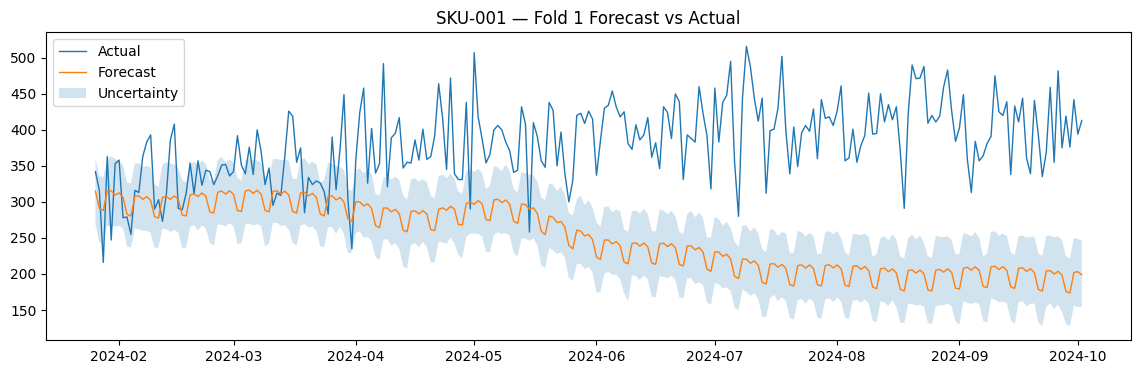

In [30]:
from prophet import Prophet

sku = "SKU-001"
fold = splits[sku]["folds"][2]

train = fold["train"]
val = fold["val"]

model = Prophet()
model.fit(train)

forecast = model.predict(val[["ds"]])

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(val["ds"], val["y"], label="Actual", linewidth=1)
ax.plot(forecast["ds"], forecast["yhat"], label="Forecast", linewidth=1)
ax.fill_between(forecast["ds"], forecast["yhat_lower"], forecast["yhat_upper"], alpha=0.2, label="Uncertainty")
ax.set_title(f"{sku} — Fold 1 Forecast vs Actual")
ax.legend()
plt.show()

In [28]:
import numpy as np

actual = val["y"].values
predicted = forecast["yhat"].values

wape = np.sum(np.abs(actual - predicted)) / np.sum(actual)
rmse = np.sqrt(np.mean((actual - predicted) ** 2))

print(f"WAPE: {wape:.3f} ({wape*100:.1f}%)")
print(f"RMSE: {rmse:.1f}")

WAPE: 0.277 (27.7%)
RMSE: 97.5


In [29]:
sku = "SKU-001"
results = []

for i, fold in enumerate(splits[sku]["folds"]):
    m = Prophet()
    m.fit(fold["train"])
    fc = m.predict(fold["val"][["ds"]])

    actual = fold["val"]["y"].values
    predicted = fc["yhat"].values

    wape = np.sum(np.abs(actual - predicted)) / np.sum(actual)
    rmse = np.sqrt(np.mean((actual - predicted) ** 2))
    results.append({"fold": i + 1, "wape": wape, "rmse": rmse})
    print(f"Fold {i+1} — WAPE: {wape*100:.1f}%  RMSE: {rmse:.1f}")

avg_wape = np.mean([r["wape"] for r in results])
avg_rmse = np.mean([r["rmse"] for r in results])
print(f"\nAverage — WAPE: {avg_wape*100:.1f}%  RMSE: {avg_rmse:.1f}")

11:26:26 - cmdstanpy - INFO - Chain [1] start processing
11:26:26 - cmdstanpy - INFO - Chain [1] done processing
11:26:27 - cmdstanpy - INFO - Chain [1] start processing
11:26:27 - cmdstanpy - INFO - Chain [1] done processing
11:26:27 - cmdstanpy - INFO - Chain [1] start processing
11:26:27 - cmdstanpy - INFO - Chain [1] done processing


Fold 1 — WAPE: 27.7%  RMSE: 97.5
Fold 2 — WAPE: 51.7%  RMSE: 140.3
Fold 3 — WAPE: 35.2%  RMSE: 155.7

Average — WAPE: 38.2%  RMSE: 131.2


11:40:05 - cmdstanpy - INFO - Chain [1] start processing
11:40:05 - cmdstanpy - INFO - Chain [1] done processing
11:40:05 - cmdstanpy - INFO - Chain [1] start processing
11:40:05 - cmdstanpy - INFO - Chain [1] done processing
11:40:05 - cmdstanpy - INFO - Chain [1] start processing
11:40:05 - cmdstanpy - INFO - Chain [1] done processing


Fold 1 — WAPE: 20.4%  RMSE: 73.4
Fold 2 — WAPE: 19.4%  RMSE: 59.7
Fold 3 — WAPE: 20.0%  RMSE: 91.5

Average — WAPE: 19.9%  RMSE: 74.9


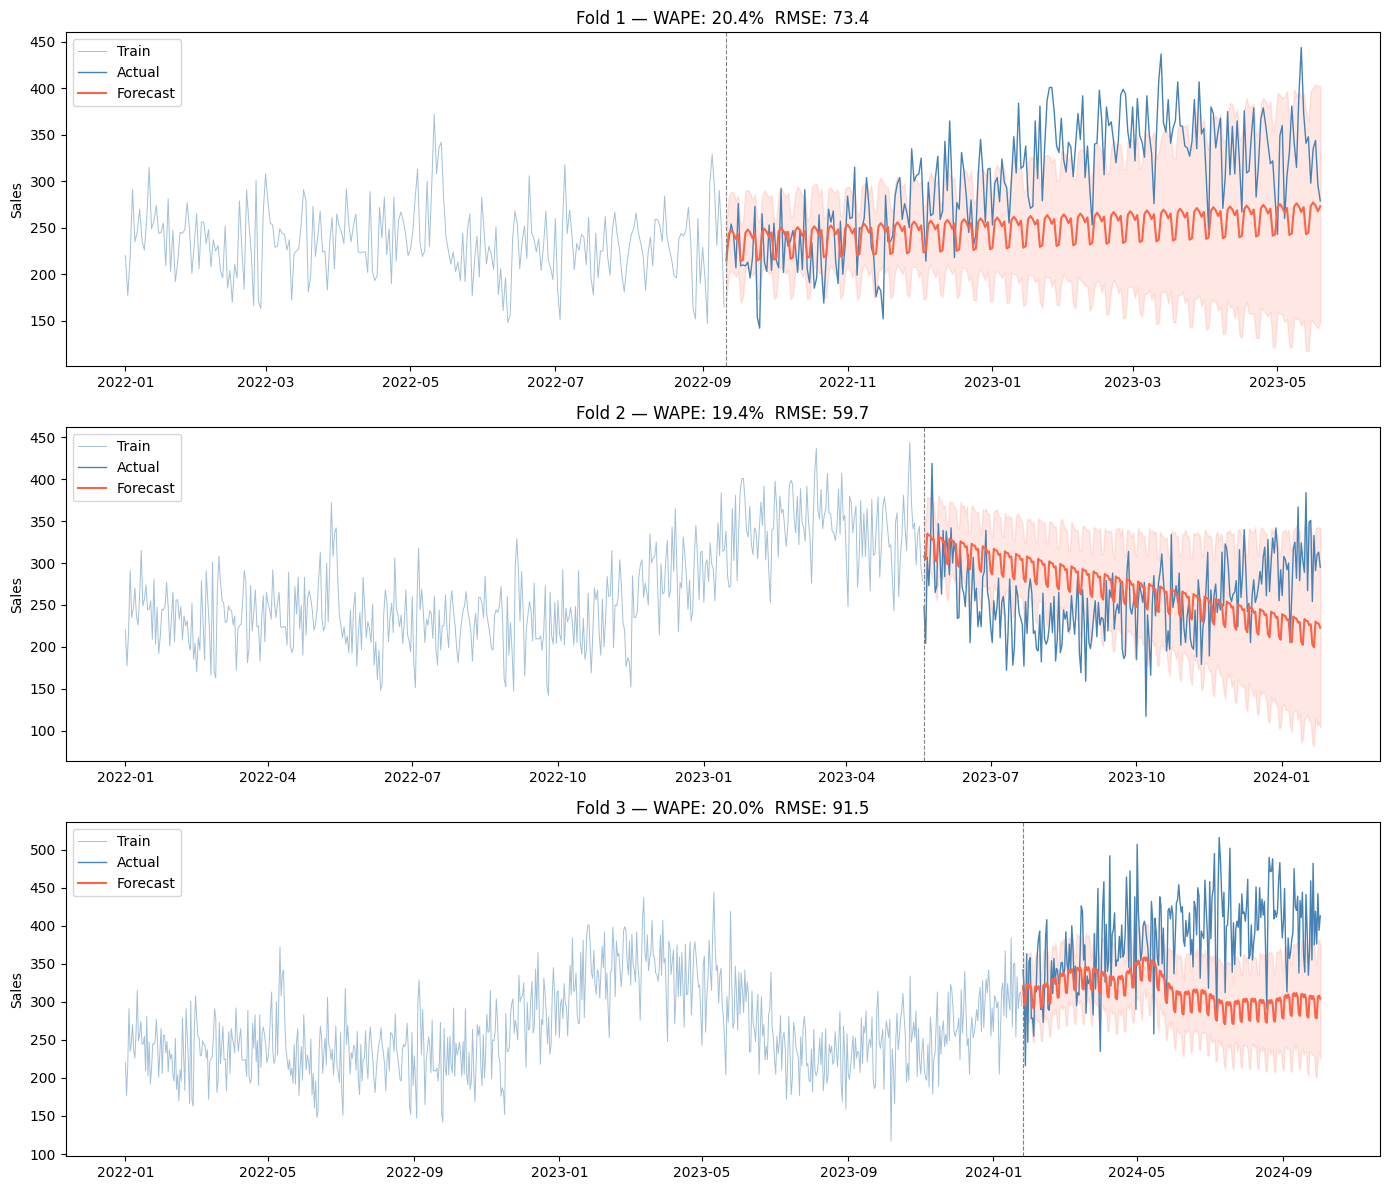

In [49]:
# --- Tune these ---
CHANGEPOINT_PRIOR_SCALE = 0.5   # default: 0.05 — try 0.1, 0.3, 0.5
CHANGEPOINT_RANGE = 0.90        # default: 0.80 — try 0.90, 0.95
SEASONALITY_MODE = "additive"    # try "multiplicative"
N_CHANGEPOINTS = 50
SEASONALITY_PRIOR_SCALE = 20
# ------------------

sku = "SKU-001"
results = []
forecasts = []

for i, fold in enumerate(splits[sku]["folds"]):
    m = Prophet(
        changepoint_prior_scale=CHANGEPOINT_PRIOR_SCALE,
        changepoint_range=CHANGEPOINT_RANGE,
        seasonality_mode=SEASONALITY_MODE,
        n_changepoints=N_CHANGEPOINTS,
        seasonality_prior_scale=SEASONALITY_PRIOR_SCALE
    )
    m.fit(fold["train"])
    fc = m.predict(fold["val"][["ds"]])

    actual = fold["val"]["y"].values
    predicted = fc["yhat"].values

    wape = np.sum(np.abs(actual - predicted)) / np.sum(actual)
    rmse = np.sqrt(np.mean((actual - predicted) ** 2))
    results.append({"fold": i + 1, "wape": wape, "rmse": rmse})
    forecasts.append((fold["train"], fold["val"], fc))
    print(f"Fold {i+1} — WAPE: {wape*100:.1f}%  RMSE: {rmse:.1f}")

avg_wape = np.mean([r["wape"] for r in results])
avg_rmse = np.mean([r["rmse"] for r in results])
print(f"\nAverage — WAPE: {avg_wape*100:.1f}%  RMSE: {avg_rmse:.1f}")

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=False)
for i, (train, val, fc) in enumerate(forecasts):
    ax = axes[i]
    ax.plot(train["ds"], train["y"], color="steelblue", linewidth=0.7, alpha=0.5, label="Train")
    ax.plot(val["ds"], val["y"], color="steelblue", linewidth=1, label="Actual")
    ax.plot(fc["ds"], fc["yhat"], color="tomato", linewidth=1.5, label="Forecast")
    ax.fill_between(fc["ds"], fc["yhat_lower"], fc["yhat_upper"], color="tomato", alpha=0.15)
    ax.axvline(val["ds"].iloc[0], color="gray", linestyle="--", linewidth=0.8)
    ax.set_title(f"Fold {i+1} — WAPE: {results[i]['wape']*100:.1f}%  RMSE: {results[i]['rmse']:.1f}")
    ax.set_ylabel("Sales")
    ax.legend(loc="upper left")

plt.tight_layout()
plt.show()

11:49:40 - cmdstanpy - INFO - Chain [1] start processing
11:49:40 - cmdstanpy - INFO - Chain [1] done processing


Test — WAPE: 10.0%  RMSE: 59.4


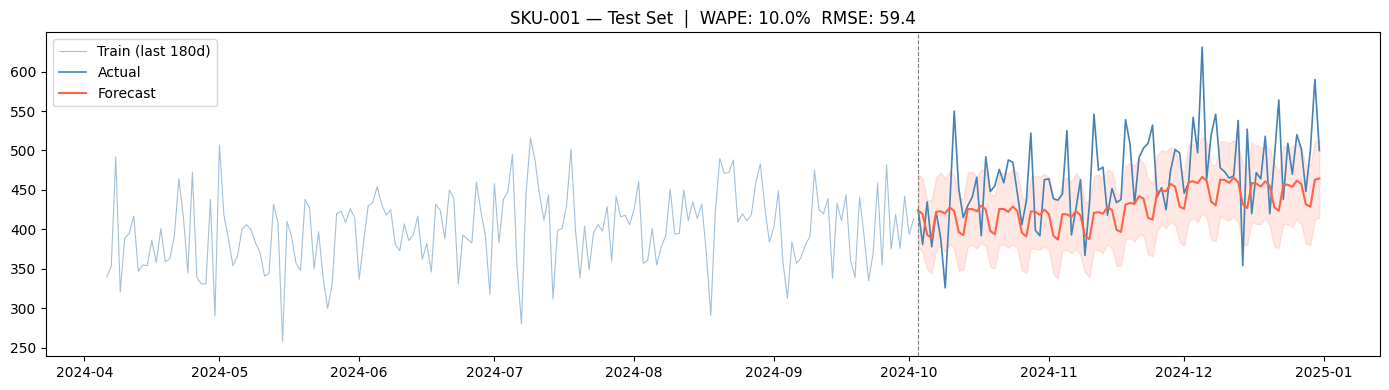

In [50]:
sku = "SKU-001"

# Train on all trainval data using best params
full_trainval = splits[sku]["folds"][-1]["train"].append(splits[sku]["folds"][-1]["val"]) if False else pd.concat([
    splits[sku]["folds"][-1]["train"],
    splits[sku]["folds"][-1]["val"]
])
test = splits[sku]["test"]

final_model = Prophet(
    changepoint_prior_scale=CHANGEPOINT_PRIOR_SCALE,
    changepoint_range=CHANGEPOINT_RANGE,
    seasonality_mode=SEASONALITY_MODE,
    n_changepoints=N_CHANGEPOINTS,
    seasonality_prior_scale=SEASONALITY_PRIOR_SCALE,
)
final_model.fit(full_trainval)
test_forecast = final_model.predict(test[["ds"]])

actual = test["y"].values
predicted = test_forecast["yhat"].values

wape = np.sum(np.abs(actual - predicted)) / np.sum(actual)
rmse = np.sqrt(np.mean((actual - predicted) ** 2))
print(f"Test — WAPE: {wape*100:.1f}%  RMSE: {rmse:.1f}")

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(full_trainval["ds"].iloc[-180:], full_trainval["y"].iloc[-180:], color="steelblue", linewidth=0.8, alpha=0.5, label="Train (last 180d)")
ax.plot(test["ds"], test["y"], color="steelblue", linewidth=1.2, label="Actual")
ax.plot(test_forecast["ds"], test_forecast["yhat"], color="tomato", linewidth=1.5, label="Forecast")
ax.fill_between(test_forecast["ds"], test_forecast["yhat_lower"], test_forecast["yhat_upper"], color="tomato", alpha=0.15)
ax.axvline(test["ds"].iloc[0], color="gray", linestyle="--", linewidth=0.8)
ax.set_title(f"{sku} — Test Set  |  WAPE: {wape*100:.1f}%  RMSE: {rmse:.1f}")
ax.legend()
plt.tight_layout()
plt.show()

## StatsForecast comparison

Same SKU, same folds, same 90-day test, same WAPE formula as the Prophet runs above, so these numbers are **directly comparable** to Prophet's. (Deliberately not using StatsForecast's own `cross_validation` here, since it windows the data differently and the numbers wouldn't line up with the folds above.)

Models: `SeasonalNaive` (the baseline floor), `AutoETS`, `AutoARIMA`, `AutoTheta`, and `MSTL`. **MSTL is the one to watch** — it models weekly *and* yearly seasonality together, which is the closest analog to what Prophet does, so it's the model most likely to match Prophet here. All are auto-tuned and run in parallel (`n_jobs=-1`); `fallback_model` guards against any model erroring.

Run all the cells above first (so `df`, `splits`, `skus` exist).

In [ ]:
from statsforecast import StatsForecast
from statsforecast.models import SeasonalNaive, AutoETS, AutoARIMA, AutoTheta, MSTL

FREQ = "D"      # daily data
WEEKLY = 7      # weekly seasonal period on daily data


def sf_score(actual, predicted):
    """Same WAPE / RMSE as the Prophet cells above, for an apples-to-apples comparison."""
    a = np.asarray(actual, float)
    p = np.asarray(predicted, float)
    wape = np.sum(np.abs(a - p)) / np.sum(a)
    rmse = np.sqrt(np.mean((a - p) ** 2))
    return wape, rmse


def build_models(train_len):
    models = [
        SeasonalNaive(season_length=WEEKLY),
        AutoETS(season_length=WEEKLY),
        AutoARIMA(season_length=WEEKLY),
        AutoTheta(season_length=WEEKLY),
    ]
    # MSTL captures weekly + yearly at once, but the yearly part needs ~2 years of history.
    models.append(MSTL(season_length=[7, 365]) if train_len >= 730 else MSTL(season_length=7))
    return models


def sf_model_cols(fc):
    """Prediction columns = everything except the ids and the -lo-/-hi- interval bounds."""
    return [c for c in fc.columns
            if c not in ("unique_id", "ds") and "-lo-" not in c and "-hi-" not in c]


In [ ]:
# --- Validation across the SAME folds Prophet used ---
SKU = "SKU-001"
rows = []

for i, fold in enumerate(splits[SKU]["folds"]):
    train = fold["train"].assign(unique_id=SKU)   # StatsForecast needs unique_id, ds, y
    val = fold["val"]

    sf = StatsForecast(
        models=build_models(len(train)),
        freq=FREQ, n_jobs=-1,
        fallback_model=SeasonalNaive(season_length=WEEKLY),
    )
    fc = sf.forecast(df=train[["unique_id", "ds", "y"]], h=len(val))

    merged = val.merge(fc, on="ds", how="left")   # align forecast to the val dates
    for mc in sf_model_cols(fc):
        wape, rmse = sf_score(merged["y"], merged[mc])
        rows.append({"fold": i + 1, "model": mc, "wape": wape, "rmse": rmse})

val_res = pd.DataFrame(rows)
print("Validation WAPE % by fold:")
print(val_res.pivot(index="model", columns="fold", values="wape").mul(100).round(1))
print("\nAverage validation WAPE % (lower is better):")
print(val_res.groupby("model")["wape"].mean().mul(100).round(1).sort_values())


In [ ]:
# --- Final test (last 90 days), fit on full trainval, just like the Prophet test cell ---
SKU = "SKU-001"
full_trainval = pd.concat([
    splits[SKU]["folds"][-1]["train"],
    splits[SKU]["folds"][-1]["val"],
]).assign(unique_id=SKU)
test = splits[SKU]["test"]

sf = StatsForecast(
    models=build_models(len(full_trainval)),
    freq=FREQ, n_jobs=-1,
    fallback_model=SeasonalNaive(season_length=WEEKLY),
)
fc = sf.forecast(df=full_trainval[["unique_id", "ds", "y"]], h=len(test), level=[80])
merged = test.merge(fc, on="ds", how="left")

cols = sf_model_cols(fc)
scores = pd.DataFrame(
    [{"model": mc, **dict(zip(["wape", "rmse"], sf_score(merged["y"], merged[mc])))} for mc in cols]
).sort_values("wape").reset_index(drop=True)

print("Test-set results  (compare to your Prophet WAPE of ~10%):")
for _, r in scores.iterrows():
    print(f"  {r['model']:<14} WAPE {r['wape']*100:4.1f}%   RMSE {r['rmse']:6.1f}")

best = scores.iloc[0]["model"]

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(full_trainval["ds"].iloc[-120:], full_trainval["y"].iloc[-120:],
        color="steelblue", linewidth=0.8, alpha=0.5, label="Train (last 120d)")
ax.plot(test["ds"], test["y"], color="black", linewidth=1.4, label="Actual")
for mc in cols:
    ax.plot(merged["ds"], merged[mc], linewidth=1.1, alpha=0.85, label=mc)
ax.fill_between(merged["ds"], merged[f"{best}-lo-80"], merged[f"{best}-hi-80"],
                alpha=0.12, color="gray", label=f"{best} 80% interval")
ax.axvline(test["ds"].iloc[0], color="gray", linestyle="--", linewidth=0.8)
ax.set_title(f"{SKU} \u2014 StatsForecast models vs Actual (test set)")
ax.legend(loc="upper left", ncol=2, fontsize=8)
plt.tight_layout()
plt.show()


## Optional: weekly granularity

You weren't sure whether to forecast daily or weekly, so this re-runs the comparison at **weekly** grain (each week = sum of its days). The yearly seasonal period becomes **52**.

**Important:** weekly WAPE is usually *lower* than daily, because summing days averages out the day-to-day noise. So don't compare the weekly number to the daily ~10% — judge each granularity against *its own* `SeasonalNaive` baseline. Note also that `AutoARIMA` with seasonal period 52 is the slow/awkward case we discussed; `MSTL` is the cleaner weekly choice.

In [ ]:
# resample daily -> weekly (sum), per SKU
weekly_df = (df.set_index("date").groupby("sku")["sales"]
               .resample("W-MON").sum()
               .reset_index().rename(columns={"date": "ds", "sales": "y"}))

SKU = "SKU-001"
wk = weekly_df[weekly_df["sku"] == SKU][["ds", "y"]].reset_index(drop=True)

TEST_WEEKS = 13                                  # ~ one quarter, comparable span to 90 days
wk_train = wk.iloc[:-TEST_WEEKS].assign(unique_id=SKU)
wk_test = wk.iloc[-TEST_WEEKS:]

WK_SEASON = 52                                   # yearly cycle on weekly data
wk_models = [SeasonalNaive(season_length=WK_SEASON), AutoETS(season_length=WK_SEASON),
             AutoARIMA(season_length=WK_SEASON), AutoTheta(season_length=WK_SEASON)]
if len(wk_train) >= 104:                         # MSTL yearly needs ~2 years of weeks
    wk_models.append(MSTL(season_length=52))

sf = StatsForecast(models=wk_models, freq="W-MON", n_jobs=-1,
                   fallback_model=SeasonalNaive(season_length=WK_SEASON))
fc = sf.forecast(df=wk_train[["unique_id", "ds", "y"]], h=TEST_WEEKS, level=[80])
merged = wk_test.merge(fc, on="ds", how="left")

print(f"Weekly test results ({TEST_WEEKS} weeks) \u2014 judge vs the weekly SeasonalNaive, not the daily 10%:")
for mc in sf_model_cols(fc):
    wape, rmse = sf_score(merged["y"], merged[mc])
    print(f"  {mc:<14} WAPE {wape*100:4.1f}%   RMSE {rmse:6.1f}")
